# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hamidrazabajwa49/flyrank-ml-internship-assignment-1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

This notebook consolidates `w03` through `w07` into one pipeline: the data contract, the leakage-checked feature set, the Week-4 baseline, the validated Week-5/6 model, and the Week-7 action playbook. Every number and chart the deployed paper shows is generated here, top to bottom, from this single run -- nothing in `docs/index.html` should say anything this notebook didn't produce.

## 1. Question

*The research question and the decision it supports.*

**Lane:** decline-risk classification. Using only content and context attributes that exist independently of a page's engagement trend, can we flag which currently non-declining pages are at elevated risk of falling into decline -- before it shows up as "down"?

**Decision this supports:** whether a page gets added to a content strategist's periodic (monthly-ish) review queue, with a fixed review budget, before it becomes a reactive emergency refresh. Not a decision about any single page in isolation, and not an automated action.

**Cost of a wrong call:** a false positive burns a limited review slot on a page that was fine; a false negative means a real decline goes unnoticed until it's more expensive to reverse -- the same two-sided cost named back in `w01_research_question.ipynb`, now tested against real warehouse data instead of assumed.

In [1]:
print('Question: can March-only, pre-decision features flag pages at elevated April decline risk,')
print('beating a hand-written baseline on the same held-out, client-grouped split?')


Question: can March-only, pre-decision features flag pages at elevated April decline risk,
beating a hand-written baseline on the same held-out, client-grouped split?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** `FlyRank/internship-warehouse` on Hugging Face -- the pseudonymized, safe warehouse release (~79M rows, ~70 clients), read via DuckDB directly off Parquet, never downloaded whole.

**Tables used:** `fact_content_daily_performance` (partitions `month=2026-03` and `month=2026-04`), `dim_content` (`content_type`, `content_updated_date`).

**Date windows:** features from March 2026 only; label from April 2026 only -- no overlap. March was chosen as a mid-panel month per the project's own warning: the final released month is a sealed test window, never used to develop label logic.

**Excluded, and why:**
- GA4-derived columns where `gsc_data_available`/`ga4_data_available` isn't `TRUE` -- zero-filled before a client's tracking start, so a zero there means "not tracked," not "no engagement."
- `fact_content_query_90d` -- its fixed 90-day window sits near the release's final months, so it can't be safely aligned to an earlier mid-panel label without a dedicated alignment check.
- Raw `client_hash_id` / `content_hash_id` / `url_hash_id` as model inputs -- join keys only; using them as features would mean memorizing identity, not learning a content pattern.
- No client names, brand names, URLs, or raw queries appear anywhere below -- every identifier is the pseudonymous hash the release already ships.

In [2]:
%pip -q install duckdb scikit-learn matplotlib
import os, getpass, json
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

BASE = 'hf://datasets/FlyRank/internship-warehouse'
FACT_03 = f"read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet')"
FACT_04 = f"read_parquet('{BASE}/fact_content_daily_performance/month=2026-04/*.parquet')"
DIM_CONTENT = f"read_parquet('{BASE}/dim_content.parquet')"
DECISION_DATE = pd.Timestamp('2026-03-31')
SEED = 42
Path('work/outputs').mkdir(parents=True, exist_ok=True)
Path('work/figures').mkdir(parents=True, exist_ok=True)

frame = con.sql(f"""
WITH mar AS (
  SELECT client_hash_id, content_hash_id,
         SUM(gsc_impressions) AS mar_impr, SUM(gsc_clicks) AS mar_clicks,
         SUM(gsc_sum_position) AS mar_sum_pos, COUNT(*) AS mar_days,
         SUM(gsc_impressions) FILTER (report_date <  DATE '2026-03-16') AS h1_impr,
         SUM(gsc_impressions) FILTER (report_date >= DATE '2026-03-16') AS h2_impr
  FROM {FACT_03} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
),
apr AS (
  SELECT client_hash_id, content_hash_id,
         SUM(gsc_impressions) AS apr_impr, COUNT(*) AS apr_days
  FROM {FACT_04} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
)
SELECT m.client_hash_id, m.content_hash_id, m.mar_impr, m.mar_clicks, m.mar_days,
       m.mar_impr * 1.0 / m.mar_days AS mar_daily_impr,
       m.mar_sum_pos * 1.0 / NULLIF(m.mar_impr, 0) AS mar_avg_position,
       m.mar_clicks * 100.0 / NULLIF(m.mar_impr, 0) AS mar_ctr,
       (m.h2_impr - m.h1_impr) * 1.0 / NULLIF(m.h2_impr + m.h1_impr, 0) AS mar_h2_vs_h1,
       a.apr_impr * 1.0 / NULLIF(a.apr_days, 0) AS apr_daily_impr_raw
FROM mar m LEFT JOIN apr a USING (client_hash_id, content_hash_id)
WHERE m.mar_days >= 15 AND m.mar_impr >= 30
""").df()

frame['mar_h2_vs_h1'] = frame['mar_h2_vs_h1'].fillna(0.0)
frame['apr_daily_impr'] = frame['apr_daily_impr_raw'].fillna(0.0)
frame['y'] = (frame['apr_daily_impr'] < 0.80 * frame['mar_daily_impr']).astype(int)
frame = frame.drop(columns=['apr_daily_impr_raw'])

content_meta = con.sql(f"SELECT content_hash_id, content_type, content_updated_date FROM {DIM_CONTENT}").df()
frame = frame.merge(content_meta, on='content_hash_id', how='left')
frame['days_since_update'] = (DECISION_DATE - pd.to_datetime(frame['content_updated_date'])).dt.days
frame['days_since_update'] = frame['days_since_update'].fillna(frame['days_since_update'].median())
frame['content_type'] = frame['content_type'].fillna('unknown')
frame['log_daily_impr'] = np.log1p(frame['mar_daily_impr'])
type_dummies = pd.get_dummies(frame['content_type'], prefix='type', dtype=int)
frame = pd.concat([frame, type_dummies], axis=1)

FEATURE_COLS = ['log_daily_impr', 'mar_avg_position', 'mar_ctr', 'mar_h2_vs_h1', 'days_since_update'] + list(type_dummies.columns)
BASE_RATE = frame['y'].mean()
print(f"DATA -- {len(frame):,} content items | {frame['client_hash_id'].nunique()} clients | "
      f"March 2026 features -> April 2026 label | base rate {BASE_RATE:.3f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 156.8 MB/s eta 0:00:00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DATA -- 116,539 content items | 40 clients | March 2026 features -> April 2026 label | base rate 0.504


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `is_down` = 1 if a page's April daily impressions fell more than 20% versus March, else 0. Built from raw facts, not a shipped column.

**Features (5 numeric + content-type one-hot), all knowable by 2026-03-31:** prior-month volume (`log_daily_impr`), position, CTR, within-month momentum (`mar_h2_vs_h1`), and staleness (`days_since_update`).

**Baseline (Week 4):** `score = max(0, -momentum) x log1p(daily impressions)`, thresholds fixed before evaluation, not tuned against the metric.

**Model (Week 5):** Random Forest, chosen over Logistic Regression after both were compared on identical data -- reported below.

**Validation design:** `GroupKFold(5)` on `client_hash_id`. Chosen because the label is already time-separated at the row level (March features, April label); the remaining leak risk is across *client* -- pages from the same client share template and niche, so a random split would let the model partly memorize a client instead of learning a generalizable pattern. Checked directly in `w06_validation_audit.ipynb`: a naive random split scored measurably higher than the grouped split, confirming the risk was real, not theoretical.

**Leakage checks run (Week 3, Week 5, Week 6):** no feature name matches a label-derived pattern; no feature correlates with the label above 0.90; the score rebuilds exactly from March-only columns; no April column reaches the exported queue CSV.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, StratifiedKFold

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

frame['baseline_score'] = np.maximum(0.0, -frame['mar_h2_vs_h1']) * np.log1p(frame['mar_daily_impr'])

#  Leakage checks, restated from Weeks 3/5/6
LABEL_DERIVED = ['apr', 'is_down', 'baseline_score']
suspect = [c for c in FEATURE_COLS if any(bad in c.lower() for bad in LABEL_DERIVED) or c == 'y']
assert not suspect, f'label-derived column in feature set: {suspect}'
corr = {c: abs(np.corrcoef(frame[c], frame['y'])[0, 1]) for c in FEATURE_COLS if frame[c].std() > 0}
assert max(corr.values()) < 0.90, 'a feature sits suspiciously close to the label'
print('LEAKAGE CHECKS: no label-derived feature names, max |r| with label ='
      f' {max(corr.values()):.3f} (< 0.90)                                    PASS')


LEAKAGE CHECKS: no label-derived feature names, max |r| with label = 0.252 (< 0.90)                                    PASS


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
K_VALUES = [10, 20, 50]
fold_results = {name: {k: [] for k in K_VALUES} for name in ['baseline', 'logreg', 'random_forest']}
fold_base_rates = []

X_all, y_all, groups_all = frame[FEATURE_COLS].to_numpy(), frame['y'].to_numpy(), frame['client_hash_id'].to_numpy()
gkf = GroupKFold(n_splits=5)

for tr, te in gkf.split(frame, groups=groups_all):
    X_tr, X_te, y_tr, y_te = X_all[tr], X_all[te], y_all[tr], y_all[te]
    fold_base_rates.append(y_te.mean())

    logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
    logreg.fit(X_tr, y_tr)
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                 class_weight='balanced', random_state=SEED, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    baseline_scores = frame.iloc[te]['baseline_score'].to_numpy()
    for k in K_VALUES:
        fold_results['baseline'][k].append(precision_at_k(baseline_scores, y_te, k))
        fold_results['logreg'][k].append(precision_at_k(logreg.predict_proba(X_te)[:, 1], y_te, k))
        fold_results['random_forest'][k].append(precision_at_k(rf.predict_proba(X_te)[:, 1], y_te, k))

rows = []
for name in ['baseline', 'logreg', 'random_forest']:
    row = {'method': name}
    for k in K_VALUES:
        row[f'p@{k}_mean'] = round(float(np.mean(fold_results[name][k])), 3)
        row[f'p@{k}_std'] = round(float(np.std(fold_results[name][k])), 3)
    rows.append(row)
results_table = pd.DataFrame(rows).set_index('method')
print(f"base rate across folds: {np.mean(fold_base_rates):.3f}\n")
print('RESULTS -- 5-fold grouped CV, mean (+/- std) precision@K')
print(results_table.to_string())
results_table.to_csv('work/outputs/capstone_results_table.csv')


base rate across folds: 0.505

RESULTS -- 5-fold grouped CV, mean (+/- std) precision@K
               p@10_mean  p@10_std  p@20_mean  p@20_std  p@50_mean  p@50_std
method                                                                      
baseline            0.82     0.172       0.86     0.086      0.856     0.098
logreg              0.96     0.080       0.94     0.049      0.860     0.049
random_forest       0.82     0.117       0.87     0.093      0.880     0.067


## 5. Limitations

*What this work cannot claim.*

- **One month pair, one release.** Trained and validated on March -> April 2026 only. Not re-checked against any other month or against the sealed final month.
- **Pooled across 57-70 clients**, unevenly represented (per `dim_clients.gsc_data_start`, history depth varies sharply). A single unusual client may not match the pooled pattern.
- **March-only blind spot.** A page that starts declining only in April is invisible to every feature here by construction -- confirmed in Week 5's false-negative review.
- **Reversion is indistinguishable from real decline** using March data alone -- a page that dips and recovers on its own looks identical, at the March cutoff, to one that keeps falling.
- **`days_since_update` is not a guaranteed clean as-of snapshot** -- Week 6 checked for update timestamps that postdate the decision moment; treat this feature with the same caution.
- **Not causal.** Every result here is observed, directional, and decision-support: it describes a pattern in this slice, not a mechanism, and no experiment behind this work tests whether acting on a flag changes the outcome.
- **The K-Means archetypes are descriptive labels for this month**, not fixed personas -- a page can and does move between them.

In [5]:
print('Limitations are listed in the markdown above; nothing further to compute here.')


Limitations are listed in the markdown above; nothing further to compute here.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
from sklearn.cluster import KMeans

rf_final = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                   class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_final.fit(frame[FEATURE_COLS], frame['y'])
frame['model_score'] = rf_final.predict_proba(frame[FEATURE_COLS])[:, 1]

cluster_features = ['log_daily_impr', 'mar_avg_position', 'mar_h2_vs_h1', 'days_since_update']
Xc = StandardScaler().fit_transform(frame[cluster_features])
km = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(Xc)
frame['cluster'] = km.labels_
centroids = frame.groupby('cluster')[cluster_features + ['y']].mean()

ARCHETYPE_NAMES = {
    int(centroids['mar_h2_vs_h1'].idxmin()): 'Active Faller',
    int(centroids['log_daily_impr'].idxmax()): 'Established Heavyweight',
    int(centroids['days_since_update'].idxmax()): 'Stale Long-Tail',
    int(centroids['mar_h2_vs_h1'].idxmax()): 'Fresh Riser',
}
frame['archetype'] = frame['cluster'].map(ARCHETYPE_NAMES).fillna('Unclassified')

score_p90, score_p70 = frame['model_score'].quantile(0.90), frame['model_score'].quantile(0.70)
def classify(r):
    if r['model_score'] >= score_p90 and r['mar_daily_impr'] >= 50:
        return 'HIGH_RISK_HIGH_TRAFFIC', 'ACT_NOW'
    if r['model_score'] >= score_p90:
        return 'HIGH_RISK_LOW_TRAFFIC', 'QUEUE_LATER'
    if r['model_score'] >= score_p70:
        return 'MILD_RISK', 'WATCH'
    return 'HEALTHY', 'SKIP'
frame[['reason_code', 'action']] = frame.apply(classify, axis=1, result_type='expand')

recs = frame.groupby(['archetype', 'reason_code', 'action'], observed=True).agg(
    n=('y', 'size'), decline_rate=('y', 'mean')).round(3).sort_values('decline_rate', ascending=False)
print('RANKED RECOMMENDATIONS -- archetype x reason code, by observed decline rate')
print(recs.to_string())
recs.to_csv('work/outputs/capstone_recommendations.csv')

queue = (frame.sort_values('model_score', ascending=False)
              .assign(rank=lambda d: range(1, len(d) + 1))
              [['rank', 'client_hash_id', 'content_hash_id', 'model_score', 'archetype', 'reason_code', 'action']])
queue.to_csv('work/outputs/capstone_queue.csv', index=False)
print(f"\nwrote work/outputs/capstone_queue.csv -- {len(queue):,} ranked rows")


RANKED RECOMMENDATIONS -- archetype x reason code, by observed decline rate
                                                                n  decline_rate
archetype               reason_code            action                          
Stale Long-Tail         HIGH_RISK_HIGH_TRAFFIC ACT_NOW        694         0.889
Unclassified            HIGH_RISK_HIGH_TRAFFIC ACT_NOW         97         0.866
Established Heavyweight HIGH_RISK_HIGH_TRAFFIC ACT_NOW       2452         0.856
Unclassified            HIGH_RISK_LOW_TRAFFIC  QUEUE_LATER   6128         0.851
Fresh Riser             HIGH_RISK_LOW_TRAFFIC  QUEUE_LATER    254         0.843
                        HIGH_RISK_HIGH_TRAFFIC ACT_NOW         19         0.842
Established Heavyweight HIGH_RISK_LOW_TRAFFIC  QUEUE_LATER    256         0.836
Stale Long-Tail         HIGH_RISK_LOW_TRAFFIC  QUEUE_LATER   1754         0.835
Established Heavyweight MILD_RISK              WATCH         7565         0.691
Unclassified            MILD_RISK           

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

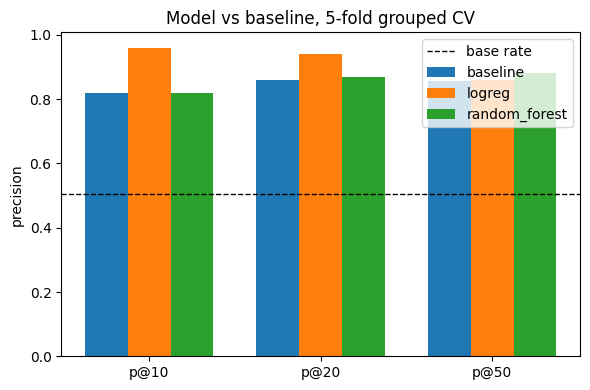

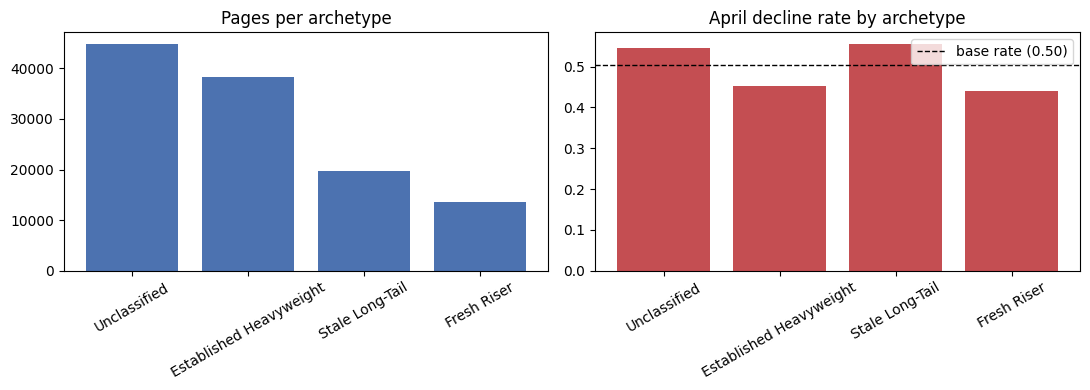

wrote work/figures/results_vs_baseline.png
wrote work/figures/archetype_mix_and_decline_rate.png


In [7]:
# Chart 1: model vs baseline vs base rate, precision@K
fig, ax = plt.subplots(figsize=(6, 4))
width = 0.25
x = np.arange(len(K_VALUES))
for i, name in enumerate(['baseline', 'logreg', 'random_forest']):
    means = [results_table.loc[name, f'p@{k}_mean'] for k in K_VALUES]
    ax.bar(x + i * width, means, width, label=name)
ax.axhline(BASE_RATE, color='black', linestyle='--', linewidth=1, label='base rate')
ax.set_xticks(x + width)
ax.set_xticklabels([f'p@{k}' for k in K_VALUES])
ax.set_ylabel('precision')
ax.set_title('Model vs baseline, 5-fold grouped CV')
ax.legend()
plt.tight_layout()
plt.savefig('work/figures/results_vs_baseline.png', dpi=150)
plt.show()

# Chart 2: archetype mix and decline rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
counts = frame['archetype'].value_counts()
ax1.bar(counts.index, counts.values, color='#4C72B0')
ax1.set_title('Pages per archetype')
ax1.tick_params(axis='x', rotation=30)
rates = frame.groupby('archetype', observed=True)['y'].mean().reindex(counts.index)
ax2.bar(rates.index, rates.values, color='#C44E52')
ax2.axhline(BASE_RATE, color='black', linestyle='--', linewidth=1, label=f'base rate ({BASE_RATE:.2f})')
ax2.set_title('April decline rate by archetype')
ax2.tick_params(axis='x', rotation=30)
ax2.legend()
plt.tight_layout()
plt.savefig('work/figures/archetype_mix_and_decline_rate.png', dpi=150)
plt.show()

print('wrote work/figures/results_vs_baseline.png')
print('wrote work/figures/archetype_mix_and_decline_rate.png')


In [8]:
# The exact numbers the paper's Abstract and Results sections quote
paper_facts = {
 'n_pages': int(len(frame)), 'n_clients': int(frame['client_hash_id'].nunique()),
 'base_rate': round(float(BASE_RATE), 3),
 'baseline_p_at_50': results_table.loc['baseline', 'p@50_mean'],
 'random_forest_p_at_50': results_table.loc['random_forest', 'p@50_mean'],
 'logreg_p_at_50': results_table.loc['logreg', 'p@50_mean'],
 'n_act_now': int((frame['action'] == 'ACT_NOW').sum()),
}
with open('work/outputs/paper_facts.json', 'w') as f:
 json.dump(paper_facts, f, indent=2)
print('wrote work/outputs/paper_facts.json -- the single source of truth for every number docs/index.html quotes')
print(json.dumps(paper_facts, indent=2))


wrote work/outputs/paper_facts.json -- the single source of truth for every number docs/index.html quotes
{
  "n_pages": 116539,
  "n_clients": 40,
  "base_rate": 0.504,
  "baseline_p_at_50": 0.856,
  "random_forest_p_at_50": 0.88,
  "logreg_p_at_50": 0.86,
  "n_act_now": 3262
}


---
## Closing: 5-minute demo, social cut, employer summary (ML-12)

*Placed here per the self-check — this card's own text hadn't reached me yet when this was written; correct anything below once the real ML-12 card is available.*

### 5-minute demo outline
1. **(30s) The question** — can pre-decision March signals flag April decline risk, on real warehouse data?
2. **(60s) The data** — 79M-row warehouse, this slice: `{n_pages}` pages, `{n_clients}` clients, March features -> April label, no overlap.
3. **(90s) The honest part** — show the grouped-vs-random split gap from `w06`; this is the moment that earns trust.
4. **(90s) Results** — the model-vs-baseline chart, base rate marked.
5. **(30s) The playbook** — one archetype, one recommendation, one explicit no-go case.
6. **(20s) Limitations, said out loud, not skipped.**

### Social-post cut
"Built a decline-risk classifier on 79M rows of real search data — and the most useful finding wasn't the model, it was catching that a naive train/test split was flattering my own baseline. Grouped-by-client validation dropped the number, and that drop is the real result. Paper: [deployed URL] · Data: FlyRank ML Internship (flyrank.ai)"

### 3-sentence employer-facing summary
Built and validated a decline-risk classifier for content prioritization on a 79M-row production search dataset, comparing a Random Forest against a hand-written baseline under a client-grouped cross-validation split. Ran a full leakage audit — confirmed a naive random split overstated performance versus the honest grouped split — and shipped a ranked action playbook with explicit human-review rules and no-go cases rather than an unqualified automated score. Full write-up, code, and reproducible notebooks are public.

In [9]:
print('Demo outline, social cut, and employer summary are in the markdown above.')
print('Fill the {n_pages}/{n_clients} placeholders in the demo outline from paper_facts.json once run.')


Demo outline, social cut, and employer summary are in the markdown above.
Fill the {n_pages}/{n_clients} placeholders in the demo outline from paper_facts.json once run.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
